# **Feature Selection - Step 1**

- Highly collinear RDKit features (0.90) were removed
- Low variance morgan fingerprints (>1%) were removed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Install RDKit
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 57.6 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [ ]:
# === Define input and output paths ===
input_path = '/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/'
output_path = '/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_1/'

# === Define filenames ===
input_file = 'mao-b_features.csv'
output_file = 'mao-b_features_reduced_1.csv'

df = pd.read_csv(input_path + input_file)
print(df.shape)
df.head()


(4840, 2269)


,molecule_chembl_id,canonical_smiles,pIC50,rdk_MaxAbsEStateIndex,rdk_MaxEStateIndex,rdk_MinAbsEStateIndex,rdk_MinEStateIndex,rdk_qed,rdk_SPS,rdk_MolWt,...,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047,activity_class
0,CHEMBL350093,N#CCCN1CC(=O)OC(c2ccc(OCc3ccccc3)cc2)=N1,7.744727,11.694346,11.694346,0.058978,-0.382089,0.758843,13.640000,335.363,...,0,0,0,1,0,0,0,0,0,active
1,CHEMBL161907,O=c1c(=O)c2ccc(OCCCC(F)(F)F)cc2c1=O,8.045757,11.923491,11.923491,0.002446,-4.239981,0.631270,11.950000,286.205,...,0,0,0,0,0,0,0,0,0,active
2,CHEMBL17079,N#CCCn1nc(-c2ccc(OCc3ccccc3)cc2)oc1=S,8.356547,8.636059,8.636059,0.268198,0.268198,0.625159,10.291667,337.404,...,0,0,0,1,0,0,0,0,0,active
3,CHEMBL160347,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,4.630784,6.007580,6.007580,0.538467,0.538467,0.918824,17.222222,310.191,...,0,0,0,0,0,0,0,0,0,inactive
4,CHEMBL347197,CCN=C1CCc2c1n(C)c1ccccc21,4.110138,4.616881,4.616881,0.885217,0.885217,0.691274,17.250000,212.296,...,0,0,0,0,0,0,0,0,0,inactive


In [ ]:
#=== Identify columns ===
meta_cols = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'activity_class']
rdkit_cols = [col for col in df.columns if col.startswith("rdk_")]
mfp_cols = [col for col in df.columns if col.startswith("fp_") or col.startswith("mp_")]

# === Separate features ===
X_rdkit = df[rdkit_cols]
X_mfp = df[mfp_cols]

In [ ]:
#X_rdkit.head()

In [ ]:
nan_counts = X_rdkit.isna().sum()
print(nan_counts[nan_counts > 0])

rdk_MaxPartialCharge       7
rdk_MinPartialCharge       7
rdk_MaxAbsPartialCharge    7
rdk_MinAbsPartialCharge    7
rdk_BCUT2D_MWHI            7
rdk_BCUT2D_MWLOW           7
rdk_BCUT2D_CHGHI           7
rdk_BCUT2D_CHGLO           7
rdk_BCUT2D_LOGPHI          7
rdk_BCUT2D_LOGPLOW         7
rdk_BCUT2D_MRHI            7
rdk_BCUT2D_MRLOW           7
dtype: int64


In [ ]:
# === Separate and Impute RDKit features ===
X_rdkit = df[rdkit_cols]
imputer_rdkit = SimpleImputer(strategy='median')
X_rdkit_imputed = pd.DataFrame(imputer_rdkit.fit_transform(X_rdkit), columns=rdkit_cols)

In [ ]:
#X_mfp.head()

In [ ]:
# === 3. Impute and filter Morgan fingerprints ===
X_mfp = df[mfp_cols]
imputer_mfp = SimpleImputer(strategy='most_frequent')  # Should be 0/1; use mode
X_mfp_imputed = pd.DataFrame(imputer_mfp.fit_transform(X_mfp), columns=mfp_cols)

In [ ]:
print(f"\n[INFO] RDKit Features: {X_rdkit.shape[1]} before correlation filtering")
print(f"[INFO] Morgan FP Features: {X_mfp.shape[1]} before variance filtering")


[INFO] RDKit Features: 217 before correlation filtering
[INFO] Morgan FP Features: 2048 before variance filtering


In [ ]:
# Define Activity classes
# Binary classification logic
def classify_activity(pIC50):
    return 'active' if pIC50 >= 7 else 'inactive'

# Apply classification
df['activity_class'] = df['pIC50'].apply(classify_activity)

# Save the updated file
df.to_csv(input_path + input_file, index=False)

In [ ]:
y = df['activity_class']

In [ ]:
# === Step 1: Remove highly correlated RDKit features ===
def remove_correlated_features(df, threshold=0.90, protected_features=None):
    if protected_features is None:
        protected_features = []

    # Compute correlation matrix
    corr_matrix = df.corr().abs()

    # Extract upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Identify columns to drop based on threshold, excluding protected
    to_drop = []
    for col in upper.columns:
        if any(upper[col] > threshold) and col not in protected_features:
            to_drop.append(col)

    # Drop the identified columns
    df_filtered = df.drop(columns=to_drop)

    # Re-add any protected features that were dropped (optional safety)
    for col in protected_features:
        if col not in df_filtered.columns and col in df.columns:
            df_filtered[col] = df[col]

    return df_filtered, to_drop


In [ ]:
# Define the Lipinski descriptors to protect
protected = ['rdk_MolWt', 'rdk_MolLogP', 'rdk_NumHDonors', 'rdk_NumHAcceptors']

# Apply filtering
X_rdkit_filtered, dropped_rdkit = remove_correlated_features(X_rdkit_imputed, threshold=0.90, protected_features=protected)

# Report
print(f"[INFO] Original RDKit feature count: {X_rdkit.shape[1]}")
print(f"[INFO] Features removed due to high correlation (r > 0.90): {len(dropped_rdkit)}")
print(f"[INFO] Remaining RDKit features after filtering: {X_rdkit_filtered.shape[1]}")


[INFO] Original RDKit feature count: 217
[INFO] Features removed due to high correlation (r > 0.90): 48
[INFO] Remaining RDKit features after filtering: 169


In [ ]:
print(f"[INFO] RDKit Features removed due to high correlation (>0.9): {len(dropped_rdkit)}")
print(f"[INFO] Remaining RDKit Features: {X_rdkit_filtered.shape[1]}")
if dropped_rdkit:
    print(f"  -> Dropped features: {dropped_rdkit}")

[INFO] RDKit Features removed due to high correlation (>0.9): 48
[INFO] Remaining RDKit Features: 169
  -> Dropped features: ['rdk_MaxEStateIndex', 'rdk_HeavyAtomMolWt', 'rdk_ExactMolWt', 'rdk_NumValenceElectrons', 'rdk_MaxAbsPartialCharge', 'rdk_MinAbsPartialCharge', 'rdk_FpDensityMorgan2', 'rdk_FpDensityMorgan3', 'rdk_BertzCT', 'rdk_Chi0', 'rdk_Chi0n', 'rdk_Chi0v', 'rdk_Chi1', 'rdk_Chi1n', 'rdk_Chi1v', 'rdk_Chi2n', 'rdk_Chi2v', 'rdk_Chi3n', 'rdk_Chi3v', 'rdk_Chi4n', 'rdk_Chi4v', 'rdk_Kappa1', 'rdk_Kappa2', 'rdk_Kappa3', 'rdk_LabuteASA', 'rdk_SlogP_VSA6', 'rdk_EState_VSA11', 'rdk_VSA_EState10', 'rdk_HeavyAtomCount', 'rdk_NHOHCount', 'rdk_NOCount', 'rdk_NumHeteroatoms', 'rdk_NumRotatableBonds', 'rdk_NumUnspecifiedAtomStereoCenters', 'rdk_Phi', 'rdk_MolMR', 'rdk_fr_Al_OH_noTert', 'rdk_fr_COO2', 'rdk_fr_C_O_noCOO', 'rdk_fr_NH1', 'rdk_fr_Nhpyrrole', 'rdk_fr_amide', 'rdk_fr_benzene', 'rdk_fr_guanido', 'rdk_fr_nitro_arom', 'rdk_fr_nitro_arom_nonortho', 'rdk_fr_phenol', 'rdk_fr_phenol_noOrth

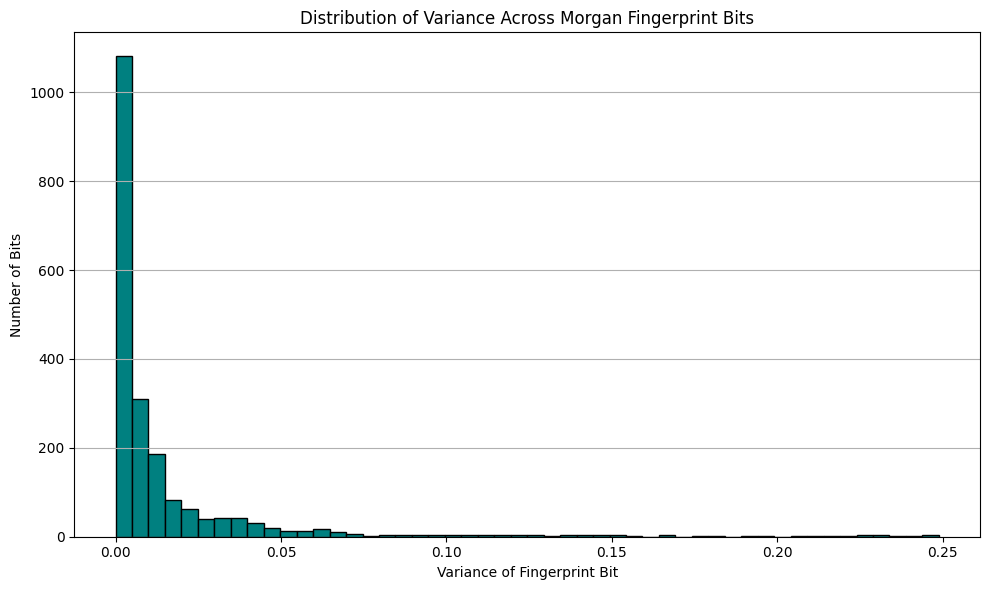

In [ ]:
# ===  Calculate variance of each fingerprint bit ===
variances = X_mfp_imputed.var()

# ===  Plot histogram of variances ===
plt.figure(figsize=(10, 6))
plt.hist(variances, bins=50, color='teal', edgecolor='black')
plt.xlabel("Variance of Fingerprint Bit")
plt.ylabel("Number of Bits")
plt.title("Distribution of Variance Across Morgan Fingerprint Bits")
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("mfp_variance_distribution.png", dpi=300)
plt.show()

- Morgan fingerprints (like ECFP) are binary vectors (0 or 1) representing substructure presence.

- Many fingerprint bits are sparse — they are 1 (i.e., substructure present) in very few molecules and 0 in most others.

- This leads to low variance for most bits.

- These bits don't help in learning tasks and can be safely removed (e.g., using a threshold like 0.01).



In [ ]:
# === Step 2: Remove low-variance MFP features ===
selector = VarianceThreshold(threshold=0.01)  # < 1% variance removed
X_mfp_filtered = selector.fit_transform(X_mfp_imputed)

# Get the indices of features that were kept
kept_mfp_indices = selector.get_support(indices=True)

# Get the indices that were dropped
all_indices = set(range(X_mfp_imputed.shape[1]))
dropped_mfp_indices = sorted(list(all_indices - set(kept_mfp_indices)))


In [ ]:
print(f"\n[INFO] MFP Features removed due to low variance (<1%): {len(dropped_mfp_indices)}")
print(f"[INFO] Remaining MFP Features: {X_mfp_filtered.shape[1]}")
if dropped_mfp_indices:
    print(f"  -> Dropped feature indices: {dropped_mfp_indices[:10]} ... (showing first 10)")



[INFO] MFP Features removed due to low variance (<1%): 1392
[INFO] Remaining MFP Features: 656
  -> Dropped feature indices: [0, 3, 4, 5, 6, 7, 10, 11, 12, 15] ... (showing first 10)


- Morgan fingerprints tend to be high-dimensional and sparse.

- Dropping low-variance bits helps reduce noise and improves model performance.

- Keeping ~600 features from an original 2048-bit fingerprint is common practice.

# **Save Reduced Feature File**

In [ ]:
# Combine metadata with filtered features
df_final = pd.concat([
    df[meta_cols].reset_index(drop=True),
    X_rdkit_filtered.reset_index(drop=True),
    pd.DataFrame(X_mfp_filtered, columns=[f'fp_{i}' for i in range(X_mfp_filtered.shape[1])])
], axis=1)

# Create directory if not exists
os.makedirs(output_path, exist_ok=True)

# Save to CSV

df_final.to_csv(output_path + output_file, index=False)
print(f" Reduced feature file saved to:\n{output_path}")


 Reduced feature file saved to:
/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_1/


# **PCA Plots by Activity Class**

In [ ]:

# === Step 3: PCA visualization function ===
def pca_plot(X, y, title, filename):
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    df_pca = pd.DataFrame(components, columns=['PC1', 'PC2'])
    df_pca['activity_class'] = y.values

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='activity_class', palette='Set2', alpha=0.7)
    plt.title(title, fontsize=14)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

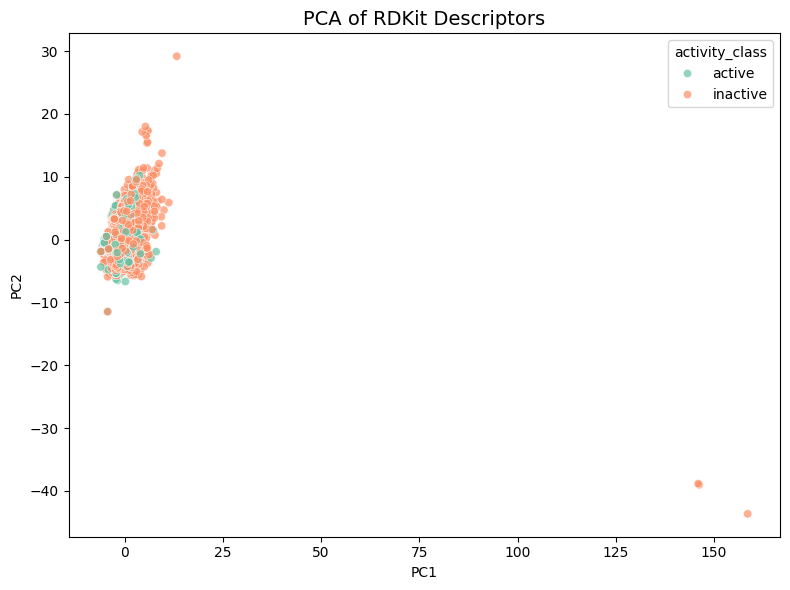

In [ ]:
# === PCA Plot: RDKit Descriptors ===
pca_plot(X_rdkit_filtered, y, "PCA of RDKit Descriptors", "pca_rdkit_combined.png")

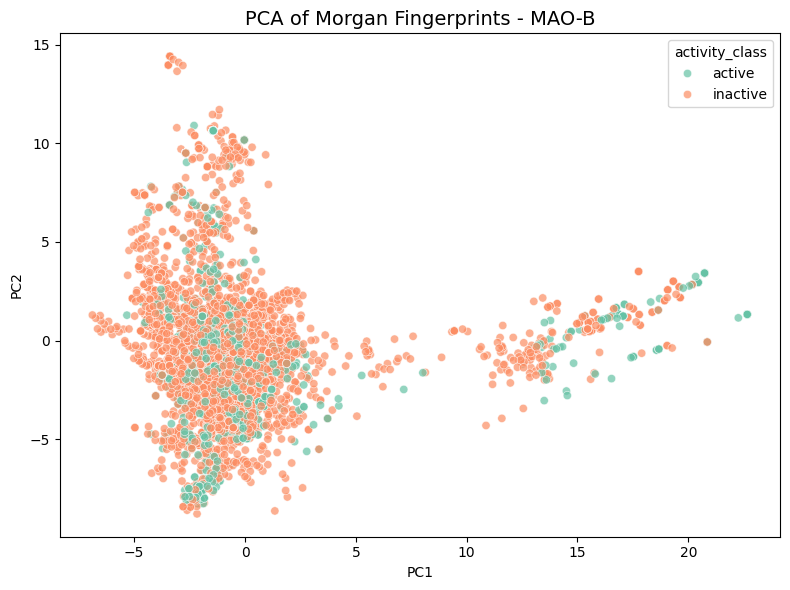

In [ ]:
# === PCA Plot: Morgan Fingerprints ===
pca_plot(pd.DataFrame(X_mfp_filtered), y, "PCA of Morgan Fingerprints - MAO-B", "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/EDA/pca_mfp_MAO-B.png")

# **Pair Plots for Lipinsky Descriptors**

<Figure size 1000x800 with 0 Axes>

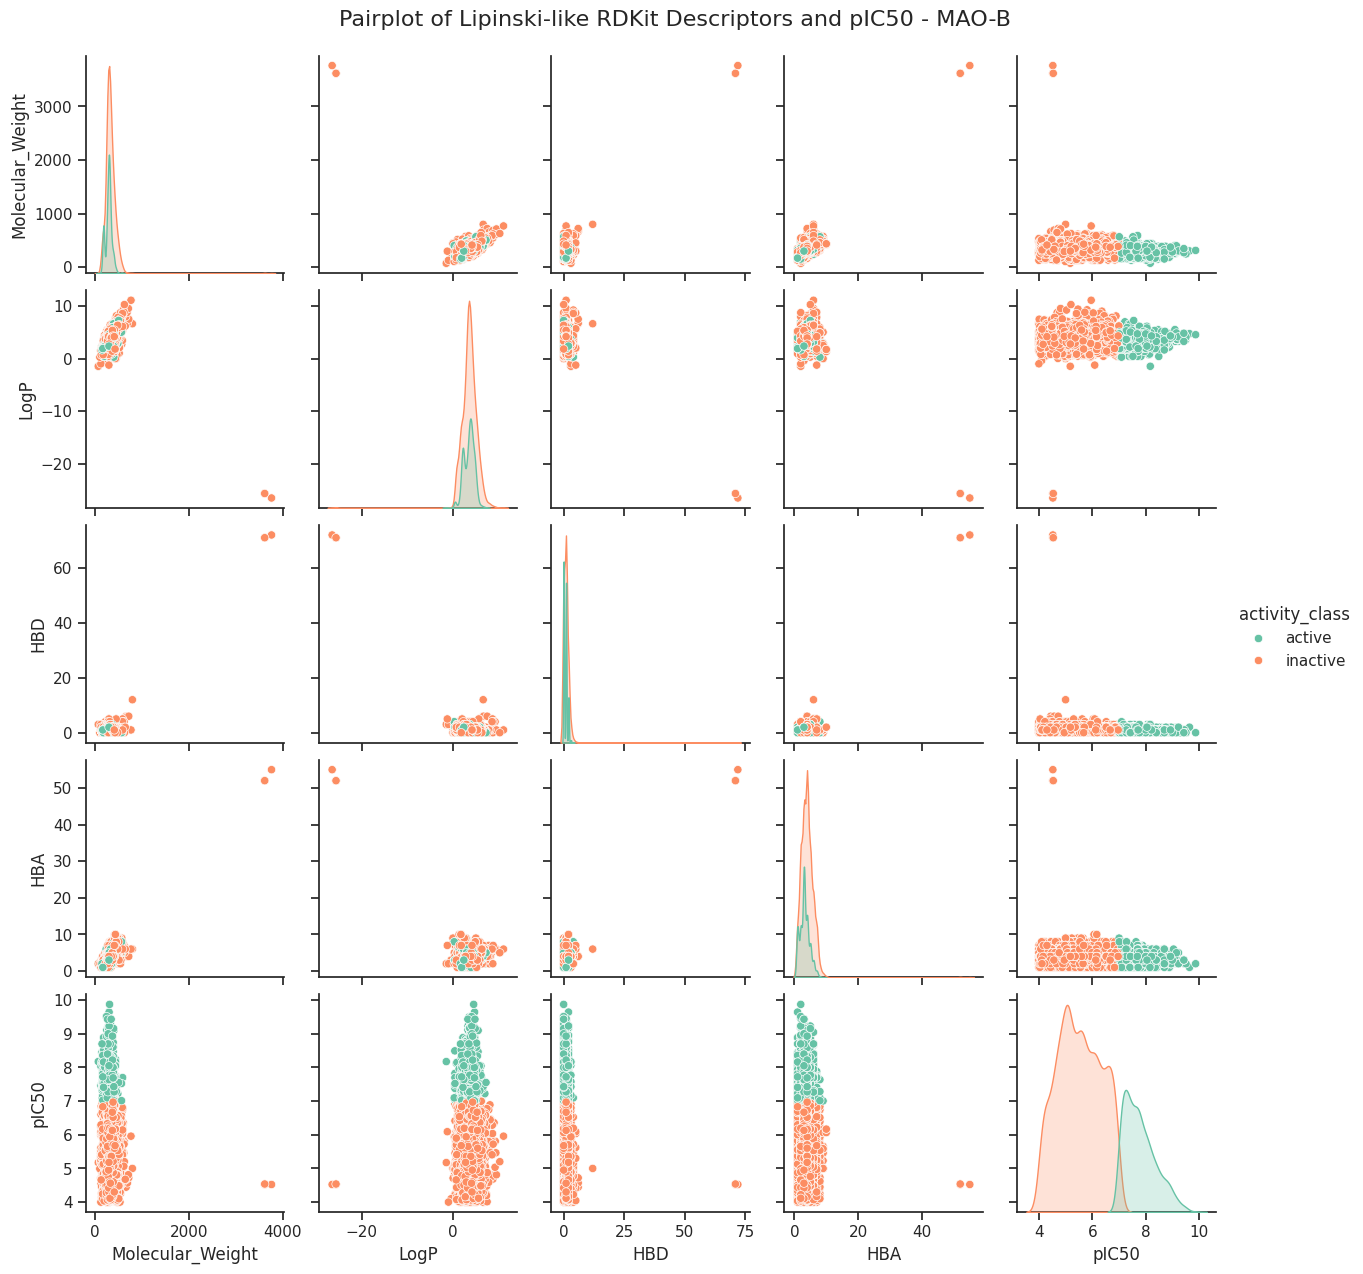

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Step 1: Map actual RDKit column names to Lipinsky descriptors ===
columns_of_interest = {
    'rdk_MolWt': 'Molecular_Weight',
    'rdk_MolLogP': 'LogP',
    'rdk_NumHDonors': 'HBD',
    'rdk_NumHAcceptors': 'HBA',
    'pIC50': 'pIC50',
    'activity_class': 'activity_class'
}

# === Step 2: Create subset with renamed columns ===
df_subset = df_final[list(columns_of_interest.keys())].rename(columns=columns_of_interest)

# === Step 3: Pairplot ===
sns.set(style="ticks")
plt.figure(figsize=(10, 8))
pair = sns.pairplot(df_subset, hue='activity_class', palette='Set2', diag_kind="kde")
pair.fig.suptitle("Pairplot of Lipinski-like RDKit Descriptors and pIC50 - MAO-B", y=1.02, fontsize=16)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/EDA/Pairplot of Lipinski-like RDKit Descriptors and pIC50 - MAO-B.png", bbox_inches='tight', dpi=300)
plt.show()



# **Molecular Weight by Activity Class**

/tmp/ipython-input-1943850457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='activity_class', y='Molecular_Weight', data=df_subset, palette='Set2')


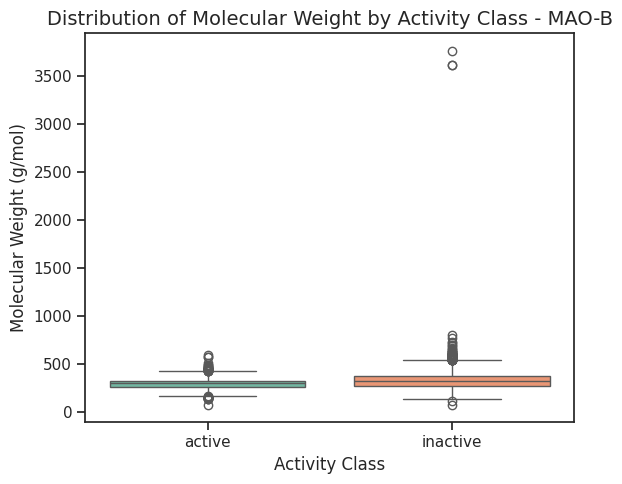

In [ ]:
# === Step 4: Boxplot of Molecular Weight by Activity Class ===
plt.figure(figsize=(6, 5))
sns.boxplot(x='activity_class', y='Molecular_Weight', data=df_subset, palette='Set2')
plt.title("Distribution of Molecular Weight by Activity Class - MAO-B", fontsize=14)
plt.xlabel("Activity Class")
plt.ylabel("Molecular Weight (g/mol)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/EDA/Distribution of Molecular Weight by Activity Class_MAO-B.png", bbox_inches='tight', dpi=300)
plt.show()


/tmp/ipython-input-714050333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


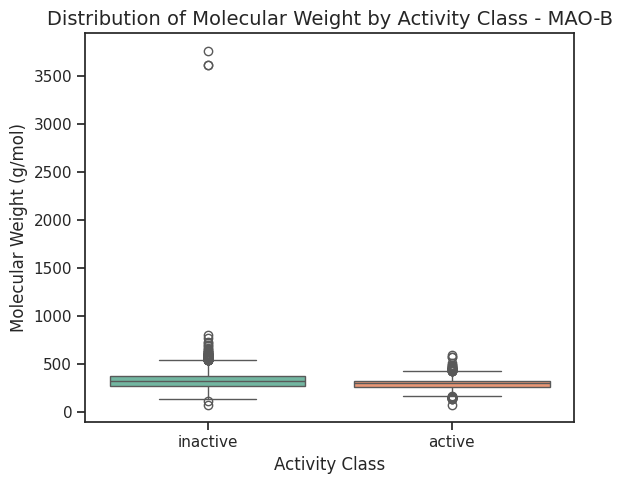

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="activity_class",
    y="Molecular_Weight",
    data=df_subset,
    palette="Set2",
    order=["inactive", "active"]   # <- inactive first
)
plt.title("Distribution of Molecular Weight by Activity Class - MAO-B", fontsize=14)
plt.xlabel("Activity Class")
plt.ylabel("Molecular Weight (g/mol)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/EDA/Distribution of Molecular Weight by Activity Class_MAO-B.png",
            bbox_inches="tight", dpi=300)
plt.show()
